# ZXZ Y tensor network factorization sweep

Created: 15-06-2026

Objectives:
* Build off [previous notebook](quspin_zxz_y_rdm_tensor_network_factorization.ipynb), sweep procedure over many parameters.
* Investigate accuracy close to critical point.

# Imports

In [5]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
from tqdm import tqdm

In [8]:
from functools import reduce

In [9]:
import quimb.tensor as qtn
import quimb as qu

# Definitions
## Groundstates

In [10]:
num_sites = 16

In [11]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [12]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [13]:
parameters = np.linspace(0, 1, 11)

In [14]:
hamiltonians = [
    get_hamiltoniain(t, num_sites)
    for t in parameters
]

In [15]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:09<00:00,  1.11it/s]


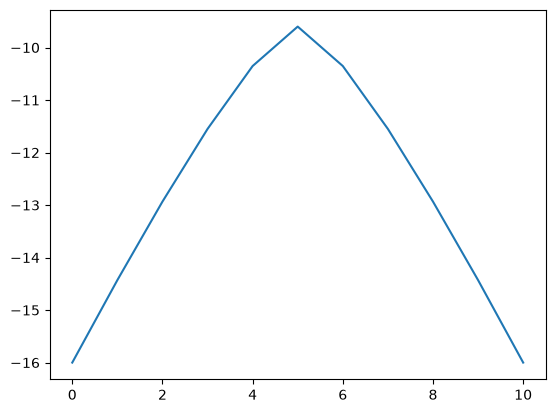

In [16]:
plt.plot(energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [17]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [18]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

## Defect operators

In [19]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [20]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [21]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [22]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [23]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [24]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [25]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [26]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [27]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [28]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [29]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [30]:
def get_tensor_network_factorization(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )

    rho_purity = np.real(np.trace(rho @ rho))

    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**4, horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**4, vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [31]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [32]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={'kl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={'bl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    left_edm = split_edm.tensors[0].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        left_edm,
        left_inds=['kl1'],
        absorb=None,
        bond_ind='v'
    )

    left_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
    )

    left_score = np.sum(s.data)

    right_edm = split_edm.tensors[2].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        right_edm,
        left_inds=['kr2'],
        absorb=None,
        bond_ind='v'
    )

    right_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    right_score = np.sum(s.data)

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant
    )

    return out

In [33]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    left_edm = split_edm.tensors[0].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        left_edm,
        left_inds=['kl1'],
        absorb=None,
        bond_ind='v'
    )

    left_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
    )

    left_score = np.sum(s.data)

    right_edm = split_edm.tensors[2].isel({'vH': 0})

    u, s, vh = qtn.tensor_core.tensor_split(
        right_edm,
        left_inds=['kr2'],
        absorb=None,
        bond_ind='v'
    )

    right_defect_operator = (
        (u & vh)
        .contract()
        .conj()
        .reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    right_score = np.sum(s.data)

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()
    
    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant
    )

    return out

In [34]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff=0.05):
    out = list()
    
    for i, sl in enumerate(left_rho_decomp.tensors[1].data):
        if sl >= cutoff:
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_rho_decomp.tensors[1].data):
                if sr >= cutoff:
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={'kl': (4, 4)}
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={'kr': (4, 4)}
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [35]:
def extract_time_reversal_information(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )
    
    rho_purity = np.real(np.trace(rho @ rho))
    
    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    A_opt, A_losses, A.loss_best = get_tensor_network_factorization(psi)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp
    )

    (
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_ouput = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_ouput.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        A_losses,
        A.loss_best,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_score,
        left_defect_op_invariant,
        right_score,
        right_defect_op_invariant,
        restricted_psi_triples
    )

    return out

# Testing

In [36]:
psi = groundstates[0]

In [37]:
test_out = extract_time_reversal_information(psi)

  0%|                                                                                                                        | 0/500 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
+0.001292467117 [best: +0.001292467117] :   4%|███                                                                  | 22/500 [00:00<00:18, 25.39it/s]


NameError: name 'A' is not defined

In [50]:
out = get_tensor_network_factorization(psi)

  0%|                                                                                                                        | 0/500 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
+0.000253677368 [best: +0.000194549561] :   5%|███▋                                                                 | 27/500 [00:00<00:09, 50.58it/s]


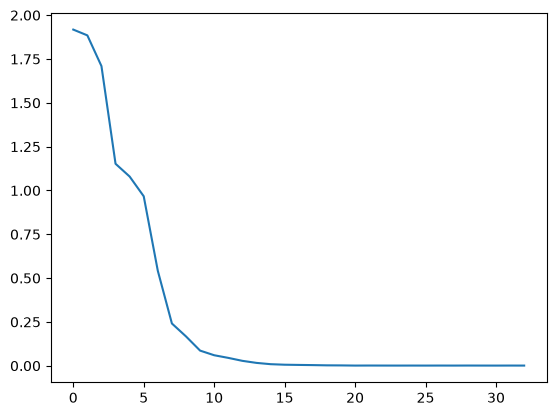

In [36]:
plt.plot(out[1])

In [40]:
A_opt = out[0]

In [41]:
out_1 = schmidt_decompose_tensor_factorization(A_opt)

In [42]:
out_1[2:]

(np.complex64(2.852853e-13+0j), np.complex64(1.0967102e-11+0j))

In [51]:
rho = basis.partial_trace(
    psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

rho_purity = np.real(np.trace(rho @ rho))

# Hardcode warning
rho_reshaped = rho.reshape((16, 16, 16, 16,))

qt_rho = qtn.Tensor(
    data=rho_reshaped,
    inds=('kl', 'kr', 'bl', 'br')
)

In [55]:
left_rho_decomp = out_1[0]
right_rho_decomp = out_1[1]

In [81]:
out_2 = get_defect_ops_and_indices_from_factorized_density_matrix(
    qt_rho,
    left_rho_decomp,
    right_rho_decomp
)

Tensor(shape=(4, 4), inds=('kr2', 'br2'), tags=oset([]), backend='numpy', dtype='complex128')


In [82]:
out_2

(array([9.68247613e-01, 6.41939830e-04, 6.05600870e-04, 3.38205554e-04,
        3.26694625e-04, 4.69230776e-05, 3.06911937e-05, 2.10111360e-05,
        9.68647753e-06, 4.72035915e-06, 2.47187058e-06, 2.28881059e-06,
        1.47554919e-06, 6.95713330e-07, 2.40697055e-07, 1.91572184e-07]),
 np.float64(1.000980116895391),
 np.complex128(0.9999999999999862-8.015421659735011e-12j),
 np.float64(1.0081208308794685),
 np.complex128(0.9999999999999977+1.6189111162745462e-10j))